## 1. Instalasi Dependensi

In [1]:
!pip uninstall -y xformers trl peft accelerate bitsandbytes unsloth

!pip install -U pip

!pip install -U unsloth

!pip install datasets matplotlib

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 48.1 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 20.4 MB/s  0:00:21
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 21.6 MB/s  0:00:15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 49.1 MB/s  0:00:05
   ━━━━━━━━━━━━

## 2. Import Library

In [1]:
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import matplotlib.pyplot as plt

print("Torch version :", torch.__version__)
print("CUDA tersedia :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch version : 2.10.0+cu128
CUDA tersedia : True
GPU            : Tesla T4


## 3. Memuat Base Model dengan QLoRA


In [3]:
MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 2048
DTYPE = None
LOAD_IN_4BIT = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)


==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


## 4. Memasang LoRA Adapter

In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

Unsloth 2026.6.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


## 5. Memuat Dataset

In [5]:
dataset_raw = load_dataset("Ichsan2895/alpaca-gpt4-indonesian", split="train")
print(dataset_raw)
print("\nContoh data sebelum mapping:")
print(dataset_raw[0])

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'input', 'output'],
    num_rows: 49969
})

Contoh data sebelum mapping:
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


In [6]:
print(dataset_raw.column_names)
print(dataset_raw[0])

['Unnamed: 0', 'input', 'output']
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


## 6. Mapping Dataset ke Chat Template (ChatML)

In [7]:
def format_chatml(example):
    messages = [
        {"role": "user", "content": example["input"]},
        {"role": "assistant", "content": example["output"]},
    ]

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    return {"text": formatted_text}

dataset = dataset_raw.map(format_chatml)

Map:   0%|          | 0/49969 [00:00<?, ? examples/s]

In [8]:
print(dataset[0]["text"])


<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang
<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>



## 7. Split Train / Validation

In [9]:
dataset_split = dataset.train_test_split(test_size=0.1, seed=3407)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

print(f"Jumlah data train : {len(train_dataset)}")
print(f"Jumlah data eval  : {len(eval_dataset)}")


Jumlah data train : 44972
Jumlah data eval  : 4997


## 8. Eksperimen Hyperparameter #1 (Baseline)

In [10]:
training_args_exp1 = TrainingArguments(
    output_dir="outputs_exp1",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    max_steps=800,
    learning_rate=2e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=400,
    save_strategy="no",
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    report_to="none",
)

trainer_exp1 = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=training_args_exp1,
)

trainer_stats_exp1 = trainer_exp1.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/44972 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4997 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
400,1.166001,1.096400


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Step,Training Loss,Validation Loss
400,1.166001,1.096400
800,1.104809,1.079148


In [11]:
import json

with open("exp1_log.json", "w") as f:
    json.dump(trainer_exp1.state.log_history, f)

model.save_pretrained("exp1_model")
tokenizer.save_pretrained("exp1_model")

print("EXP1 berhasil disimpan")

Unsloth: Restored added_tokens_decoder metadata in exp1_model/tokenizer_config.json.


EXP1 berhasil disimpan


## 9. Eksperimen Hyperparameter #2 (Pembanding)

In [12]:
model_exp2, tokenizer_exp2 = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=1024,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

model_exp2 = FastLanguageModel.get_peft_model(
    model_exp2,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [13]:
training_args_exp2 = TrainingArguments(
    output_dir="outputs_exp2",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=6,
    max_steps=800,
    learning_rate=2e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=20,
    eval_strategy="no",
    save_strategy="no",
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    report_to="none",
)

trainer_exp2 = SFTTrainer(
    model=model_exp2,
    tokenizer=tokenizer_exp2,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=training_args_exp2,
)

trainer_stats_exp2 = trainer_exp2.train()

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/44972 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/4997 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 6
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 6 x 1) = 6
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss
20,1.382784
40,1.228813
60,1.163471
80,1.147893
100,1.172710
120,1.159807
140,1.128046
160,1.162813
180,1.159954
200,1.195366


In [14]:
with open("exp2_log.json", "w") as f:
    json.dump(trainer_exp2.state.log_history, f)

model_exp2.save_pretrained("exp2_model")
tokenizer_exp2.save_pretrained("exp2_model")

print("EXP2 berhasil disimpan")

Unsloth: Restored added_tokens_decoder metadata in exp2_model/tokenizer_config.json.


EXP2 berhasil disimpan


## 10. Perbandingan Kurva Loss Kedua Eksperimen

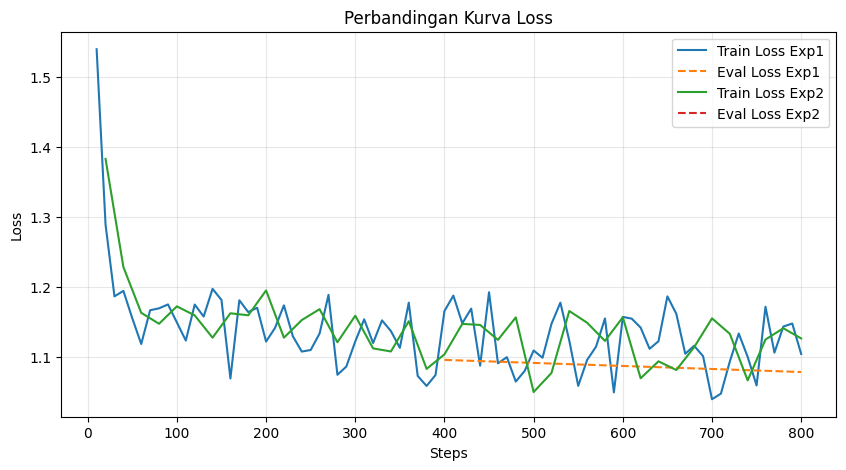

In [15]:
import matplotlib.pyplot as plt

with open("exp1_log.json", "r") as f:
    exp1_history = json.load(f)

with open("exp2_log.json", "r") as f:
    exp2_history = json.load(f)

def get_loss_history(log_history):
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []

    for log in log_history:
        if "loss" in log and "eval_loss" not in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])

        if "eval_loss" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])

    return train_steps, train_losses, eval_steps, eval_losses


t1_steps, t1_loss, e1_steps, e1_loss = get_loss_history(exp1_history)
t2_steps, t2_loss, e2_steps, e2_loss = get_loss_history(exp2_history)

plt.figure(figsize=(10,5))

plt.plot(t1_steps, t1_loss, label="Train Loss Exp1")
plt.plot(e1_steps, e1_loss, "--", label="Eval Loss Exp1")

plt.plot(t2_steps, t2_loss, label="Train Loss Exp2")
plt.plot(e2_steps, e2_loss, "--", label="Eval Loss Exp2")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Perbandingan Kurva Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("loss_comparison.png", dpi=150)
plt.show()

1. Eval Loss EXP1 lebih rendah dan lebih stabil
- Eval Loss Exp1 (oranye) turun dari sekitar 1.10 → 1.08.
- Eval Loss Exp2 (merah) berada sedikit di atasnya hampir sepanjang training.

eval loss lebih penting daripada train loss, karena menunjukkan kemampuan generalisasi model.


## 11. Uji Coba Cepat Model Terbaik


In [20]:
best_model = model
best_tokenizer = tokenizer

FastLanguageModel.for_inference(best_model)

test_messages = [
    {"role": "user", "content": "Apa itu PKWT menurut PP 35 Tahun 2021?"}
]

inputs = best_tokenizer.apply_chat_template(
    test_messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
).to("cuda")

outputs = best_model.generate(
    input_ids=inputs,
    max_new_tokens=256,
    use_cache=True
)

print(best_tokenizer.decode(outputs[0], skip_special_tokens=True))

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
Apa itu PKWT menurut PP 35 Tahun 2021?
assistant
PKWT (Pengakuan Kewarganegaraan Wilayah Tempatan) adalah undang-undang yang dikeluarkan oleh Presiden Republik Indonesia sebagai Peraturan Presiden Nomor 35 tahun 2021. Undang-undang ini mengatur proses pengakuan kewarganegaraan wilayah tempatan bagi warga negara asing (WNA) yang tinggal di Indonesia dan memenuhi syarat tertentu.

Secara singkat, PKWT mengatur proses pengakuan kewarganegaraan wilayah tempatan bagi WNA yang tinggal di Indonesia selama lebih dari 10 tahun terakhir dan telah berstatus WNA selama setidaknya 5 tahun sebelum pengajuan. Syarat lain untuk pengakuan kewarganegaraan wilayah tempatan meliputi ketidakmampuan untuk mengemban tugas pemerintah atau pekerjaan strategis, serta tidak memiliki pasangan atau anak Indonesia.

PKWT membuka peluang bagi WNA yang memenuhi syarat untuk menjadi penduduk Indonesia, memberikan mereka hak-hak dan kewaji

## 12. Push Model ke Hugging Face Hub (merged_16bit)


In [22]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    from getpass import getpass
    HF_TOKEN = getpass("Masukkan Hugging Face access token (write): ")

HF_REPO_NAME = "snssamuel/qwen2.5-3b-legal-chatbot-id"

best_model.push_to_hub_merged(
    HF_REPO_NAME,
    best_tokenizer,
    save_method="merged_16bit",
    token=HF_TOKEN,
)

print(f"Model berhasil diunggah ke: https://huggingface.co/{HF_REPO_NAME}")


No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpvrfrwopq/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpvrfrwopq/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0002-of-00002.safetensors:   0%|          | 1.20MB / 2.20GB            



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [05:24<00:00, 162.29s/it]


Unsloth: Merge process complete. Saved to `/tmp/tmpvrfrwopq`
Model berhasil diunggah ke: https://huggingface.co/snssamuel/qwen2.5-3b-legal-chatbot-id
